# NB3 — Online simulation: the live act → reward → learn loop

The static log can't replay a live loop, but the NB2 reward model can *simulate* one:
at each round the policy picks an arm, the simulator samples `click ~ Bernoulli(q̂)`.
**Honest label:** ground truth here is the logistic model, not reality — this measures
learning dynamics, and gives NB4 the "simulated truth" column for the policies that
were also evaluated offline.

Policies: uniform (=RandomPolicy), greedy (model argmax, ε=0), model-ε-greedy (ε=0.1,
the exact NB2 OPE target), a learning ε-greedy (running means), LinUCB and LinTS
(contextual, via mabwiser). All at the fixed center slot.

In [1]:
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from src import config
from src.obd_io import affinity_cols
from src.online_sim import (Simulator, RandomPolicy, EpsGreedyBandit, ModelEpsGreedy,
                            LinUCBPolicy, LinTSPolicy, run_policy)

In [2]:
ev = pd.read_parquet(config.DATA / "obd_eval.parquet")
train = pd.read_parquet(config.DATA / "obd_train.parquet")
model = joblib.load(config.ARTIFACTS / "reward_model.joblib")
est_rewards = model.predict_all(ev)                    # simulator truth (n, 80, 3)
# Contextual policies use a PCA-10 projection of the 80 affinity dims
# (fit on TRAIN contexts — no reward leakage; affinity is 95% zeros so 10 PCs suffice).
PCA_DIM = 10
pca = PCA(n_components=PCA_DIM, random_state=config.SEED).fit(
    model.scaler.transform(train[affinity_cols(train)].to_numpy(np.float64)))
contexts = pca.transform(model.scaler.transform(ev[affinity_cols(ev)].to_numpy(np.float64)))
print("stream:", est_rewards.shape, "| PCA contexts:", contexts.shape,
      "| explained var:", round(pca.explained_variance_ratio_.sum(), 3))
print("simulated at position index 1 (center)")

stream: (40000, 80, 3) | PCA contexts: (40000, 10) | explained var: 0.16
simulated at position index 1 (center)


In [3]:
T = min(20_000, est_rewards.shape[0])     # cap for runtime; identical T for all policies
specs = {
    "uniform (random)": lambda s: RandomPolicy(est_rewards.shape[1], rng=np.random.default_rng(s)),
    "greedy (model argmax, eps=0)": lambda s: ModelEpsGreedy(est_rewards, eps=0.0, seed=s),
    "model eps-greedy (eps=0.1)": lambda s: ModelEpsGreedy(est_rewards, eps=0.1, seed=s),
    "learning eps-greedy (eps=0.1)": lambda s: EpsGreedyBandit(est_rewards.shape[1], eps=0.1, rng=np.random.default_rng(s)),
    "LinUCB (mabwiser)": lambda s: LinUCBPolicy(est_rewards.shape[1], dim=contexts.shape[1], alpha=1.0, l2_lambda=1.0, seed=s),
    "LinTS (mabwiser)": lambda s: LinTSPolicy(est_rewards.shape[1], dim=contexts.shape[1], alpha=1.0, l2_lambda=1.0, seed=s),
}
results, curves = {}, {}
for i, (name, make) in enumerate(specs.items()):
    pol = make(100 + i)
    sim = Simulator(est_rewards, seed=42 + i)
    ctx = contexts if isinstance(pol, (LinUCBPolicy, LinTSPolicy)) else None
    res = run_policy(pol, sim, T=T, contexts=ctx)
    results[name] = res
    curves[name] = res["mean_ctr_curve"]
    print(f"{name:34s} final CTR={res['final_ctr']:.4f}  overall={res['overall_ctr']:.4f}")

uniform (random)                   final CTR=0.0040  overall=0.0033
greedy (model argmax, eps=0)       final CTR=0.0060  overall=0.0060
model eps-greedy (eps=0.1)         final CTR=0.0020  overall=0.0053
learning eps-greedy (eps=0.1)      final CTR=0.0080  overall=0.0026
LinUCB (mabwiser)                  final CTR=0.0040  overall=0.0022
LinTS (mabwiser)                   final CTR=0.0000  overall=0.0024


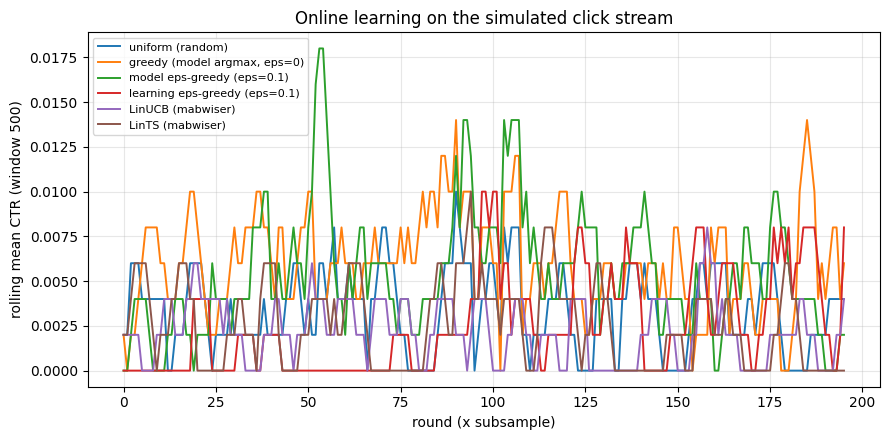

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, c in curves.items():
    ax.plot(range(len(c)), c, label=name, lw=1.4)
ax.set_xlabel("round (x subsample)")
ax.set_ylabel("rolling mean CTR (window 500)")
ax.set_title("Online learning on the simulated click stream")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(config.ARTIFACTS / "nb3_curves.png", dpi=120)
plt.show()

In [5]:
top_share = {n: max(r["pulls"].values()) / r["T"] for n, r in results.items()}
print(pd.DataFrame({
    "final_ctr": {n: r["final_ctr"] for n, r in results.items()},
    "overall_ctr": {n: r["overall_ctr"] for n, r in results.items()},
    "top_arm_share": top_share,
    "n_arms_tried": {n: len(r["pulls"]) for n, r in results.items()},
}).round(4))

                               final_ctr  overall_ctr  top_arm_share  \
uniform (random)                   0.004       0.0033         0.0149   
greedy (model argmax, eps=0)       0.006       0.0060         1.0000   
model eps-greedy (eps=0.1)         0.002       0.0054         0.9000   
learning eps-greedy (eps=0.1)      0.008       0.0026         0.5440   
LinUCB (mabwiser)                  0.004       0.0022         0.0445   
LinTS (mabwiser)                   0.000       0.0024         0.0212   

                               n_arms_tried  
uniform (random)                         80  
greedy (model argmax, eps=0)              1  
model eps-greedy (eps=0.1)               80  
learning eps-greedy (eps=0.1)            80  
LinUCB (mabwiser)                        80  
LinTS (mabwiser)                         80  


## Before vs After online simulation
`early_ctr` = mean CTR over the FIRST window (the policy's "before" state, mostly
exploration), `final_ctr` = mean CTR over the LAST window ("after" — converged). A
positive **delta** is the online-learning gain. IMPORTANT: the no-learning policies
(uniform, greedy, model-eps) do NOT learn — their delta is just Monte-Carlo noise.
Only the *learning* policies (learning ε-greedy, LinUCB, LinTS) should show a real
before→after improvement.

In [6]:
before_after = pd.DataFrame({
    "policy": list(results),
    "early_ctr (before)": [r["early_ctr"] for r in results.values()],
    "final_ctr (after)": [r["final_ctr"] for r in results.values()],
}).assign(delta=lambda d: d["final_ctr (after)"] - d["early_ctr (before)"])
print("=== BEFORE vs AFTER online simulation ===")
print(before_after.set_index("policy").round(5).sort_values("delta", ascending=False))

baseline = results["uniform (random)"]["final_ctr"]
print(f"uniform-armed baseline final_ctr = {baseline:.5f}")

(config.ARTIFACTS / "online_results.json").write_text(json.dumps({
    "T": int(T),
    "simulator": "Bernoulli(qhat) from NB2 reward model, fixed center slot",
    "policies": {n: {"early_ctr": r["early_ctr"], "final_ctr": r["final_ctr"],
                     "overall_ctr": r["overall_ctr"], "pulls": r["pulls"]}
                 for n, r in results.items()},
    "before_vs_after": {n: {"early": r["early_ctr"], "final": r["final_ctr"],
                            "delta": r["final_ctr"] - r["early_ctr"]}
                        for n, r in results.items()},
    "uniform_baseline_final_ctr": float(baseline),
}, indent=2))
print("saved artifacts/online_results.json")

=== BEFORE vs AFTER online simulation ===
                               early_ctr (before)  final_ctr (after)  delta
policy                                                                     
learning eps-greedy (eps=0.1)               0.000              0.008  0.008
greedy (model argmax, eps=0)                0.002              0.006  0.004
uniform (random)                            0.002              0.004  0.002
model eps-greedy (eps=0.1)                  0.000              0.002  0.002
LinUCB (mabwiser)                           0.002              0.004  0.002
LinTS (mabwiser)                            0.002              0.000 -0.002
uniform-armed baseline final_ctr = 0.00400
saved artifacts/online_results.json


## What to expect / conclude
- **Uniform** lands near the slot-1 average CTR (~0.005): the no-information baseline.
- **Learning ε-greedy** should beat uniform by concentrating on empirically-good arms.
- **Model-greedy / model-ε-greedy** start strong *if the model is right* — but they
  never learn, they inherit model bias. Their simulated CTR is exactly what NB4
  compares against the OPE estimates from NB2.
- **LinUCB / LinTS** use the PCA-10 context and can adapt per user; watch whether
  their final CTR tops the non-contextual policies, and how much they explore
  (top-arm share < 100% means sustained exploration).
- **Before/after (the online-learning gain):** look at the delta column. Positive
  delta on the *learning* policies (learning ε-greedy, LinUCB, LinTS) = the lift from
  doing online simulation; ~zero delta on the no-learning policies is expected (MC noise).